In [4]:
import pandas as pd

df = pd.read_excel("/Users/kittsm/Desktop/Retail_sales_Analysis/Online Retail.xlsx")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
df.shape

(541909, 8)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [8]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [9]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(5268)

In [11]:
df[df['Quantity'] < 0].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548.0,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
939,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897.0,United Kingdom


In [12]:
df[df['UnitPrice'] < 0].head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


In [13]:
# Step 1: Remove cancelled orders
df_clean = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
print(df_clean.shape)

(532621, 8)


In [14]:
# Step 2: Remove bad debt adjustment rows
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('A')]
print(df_clean.shape)

(532618, 8)


In [15]:
# Step 3: Drop rows with missing CustomerID
df_clean = df_clean.dropna(subset=['CustomerID'])
print(df_clean.shape)
print(df_clean.isnull().sum())

(397924, 8)
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [16]:
# Step 4: Remove duplicate rows
print("Before:", df_clean.duplicated().sum(), "duplicates")
df_clean = df_clean.drop_duplicates()
print("After:", df_clean.shape)

Before: 5192 duplicates
After: (392732, 8)


In [17]:
# Step 5: Fix CustomerID data type
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)
df_clean.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID              int64
Country                object
dtype: object

In [18]:
# Step 6: Create TotalPrice column (Quantity x UnitPrice = revenue per line item)
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']
df_clean[['Quantity', 'UnitPrice', 'TotalPrice']].head()

,Quantity,UnitPrice,TotalPrice
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [19]:
df_clean[['Quantity', 'UnitPrice', 'TotalPrice']].describe()

,Quantity,UnitPrice,TotalPrice
count,392732.000000,392732.000000,392732.000000
mean,13.153718,3.125596,22.629195
std,181.588420,22.240725,311.083465
min,1.000000,0.000000,0.000000
25%,2.000000,1.250000,4.950000
50%,6.000000,1.950000,12.390000
75%,12.000000,3.750000,19.800000
max,80995.000000,8142.750000,168469.600000


In [20]:
print("Rows:", df_clean.shape[0])
print("Columns:", df_clean.shape[1])
print("Date range:", df_clean['InvoiceDate'].min(), "to", df_clean['InvoiceDate'].max())
print("Unique customers:", df_clean['CustomerID'].nunique())
print("Unique products:", df_clean['StockCode'].nunique())
print("Unique countries:", df_clean['Country'].nunique())

Rows: 392732
Columns: 9
Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00
Unique customers: 4339
Unique products: 3665
Unique countries: 37


In [21]:
top_products = df_clean.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
print(top_products)

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64


In [22]:
country_sales = df_clean.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)
print(country_sales)

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: TotalPrice, dtype: float64


In [23]:
# Check the suspicious 80,995-quantity order
df_clean[df_clean['Quantity'] == 80995]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446,United Kingdom,168469.6


In [24]:
# Check free items
df_clean[df_clean['UnitPrice'] == 0].head(10)
print("Number of zero-price rows:", (df_clean['UnitPrice'] == 0).sum())

Number of zero-price rows: 40


In [25]:
df_clean[df_clean['UnitPrice'] == 0][['Description', 'Quantity', 'Country']]

,Description,Quantity,Country
9302,ROUND CAKE TIN VINTAGE GREEN,1,Germany
33576,ADVENT CALENDAR GINGHAM SACK,4,United Kingdom
40089,REGENCY CAKESTAND 3 TIER,10,EIRE
47068,PAPER BUNTING RETROSPOT,24,United Kingdom
47070,PLASTERS IN TIN SKULLS,24,United Kingdom
56674,ORGANISER WOOD ANTIQUE WHITE,1,United Kingdom
86789,FAIRY CAKES NOTEBOOK A6 SIZE,16,United Kingdom
130188,CERAMIC BOWL WITH LOVE HEART DESIGN,36,United Kingdom
139453,MINI CAKE STAND HANGING STRAWBERY,5,United Kingdom
145208,HEART GARLAND RUSTIC PADDED,2,United Kingdom


In [26]:
# Remove generic "Manual" adjustment entries
df_clean = df_clean[df_clean['Description'] != 'Manual']
print(df_clean.shape)

(392447, 9)


In [27]:
# Remove the extreme outlier transaction
df_clean = df_clean[df_clean['Quantity'] != 80995]
print(df_clean.shape)

(392446, 9)


In [ ]:
%pip install matplotlib seaborn

  Using cached matplotlib-3.11.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (80 kB)
  Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp313-cp313-macosx_10_13_universal2.whl.metadata (118 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.1 kB)
  Using cached pillow-12.3.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (9.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.11.0-cp313-cp313-macosx_11_0_arm64.whl (9.3 MB)
Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl (274 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.63.0-cp313-cp313-macosx_10_13_universal2.whl (2.9 MB)
Using cached kiwisolver-1.5.0-cp313-cp313-macosx_11_0_arm64.whl (64 kB)
Using cached pillow-12.3.0-cp313-cp313-macosx_11_0_arm64.whl (4.8 MB)
Using cached pyparsing-3.3.2

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

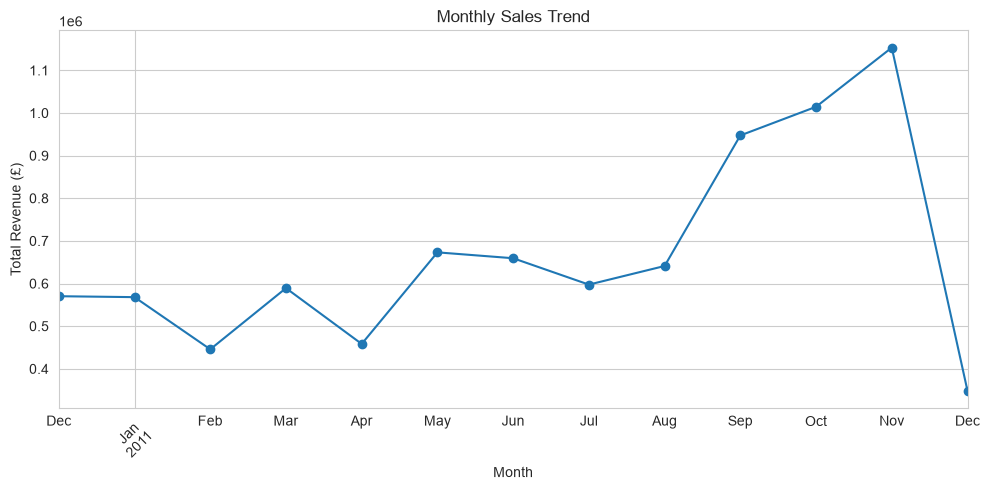

In [31]:
# Create a Year-Month column
df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M')

monthly_sales = df_clean.groupby('YearMonth')['TotalPrice'].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

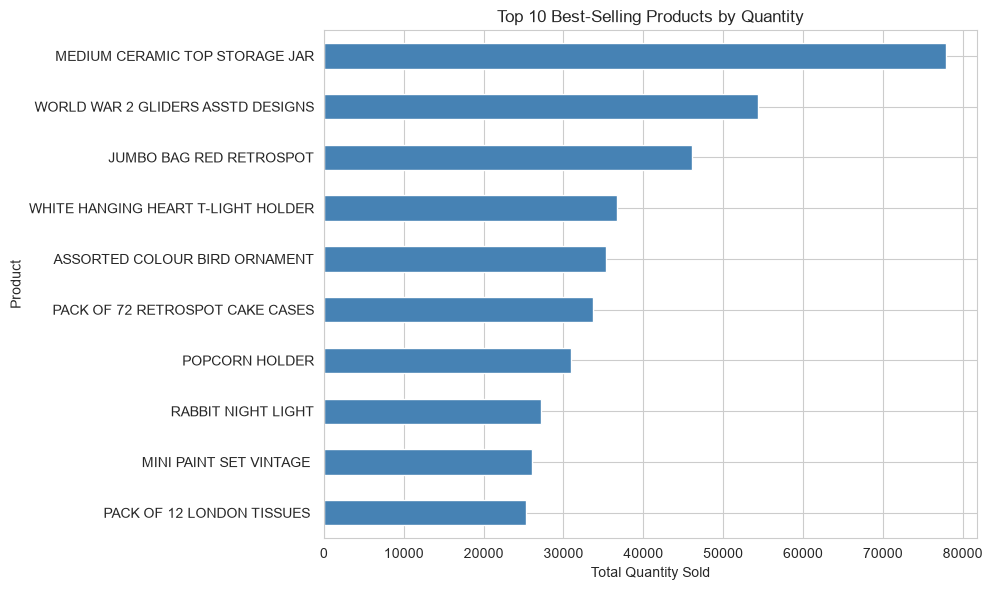

In [32]:
top_products = df_clean.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_products.plot(kind='barh', color='steelblue')
plt.title('Top 10 Best-Selling Products by Quantity')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

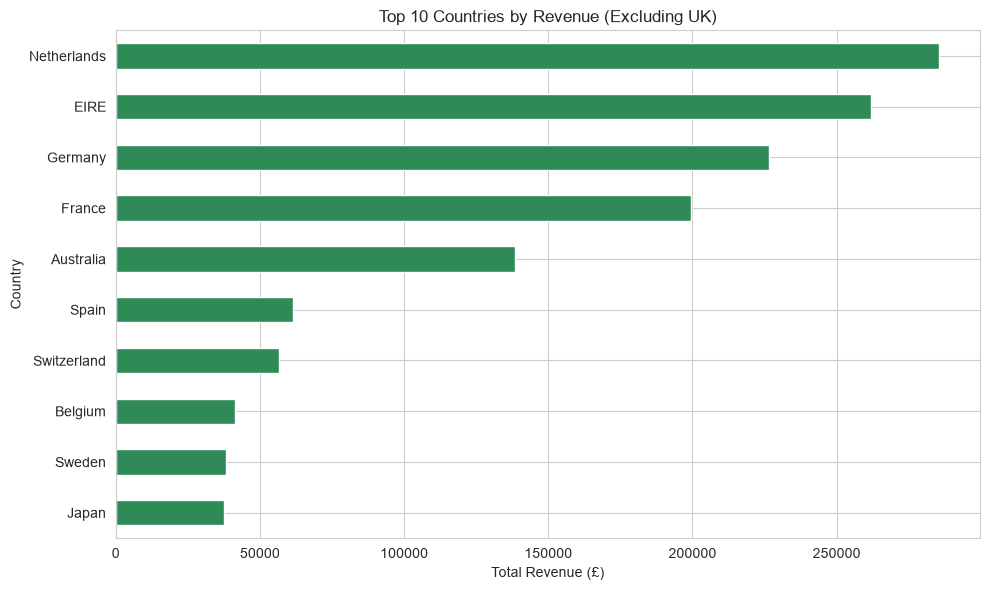

In [33]:
# Revenue by country, excluding UK (since it dominates)
country_sales = df_clean[df_clean['Country'] != 'United Kingdom'].groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
country_sales.plot(kind='barh', color='seagreen')
plt.title('Top 10 Countries by Revenue (Excluding UK)')
plt.xlabel('Total Revenue (£)')
plt.ylabel('Country')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [34]:
uk_share = df_clean[df_clean['Country'] == 'United Kingdom']['TotalPrice'].sum() / df_clean['TotalPrice'].sum() * 100
print(f"UK share of total revenue: {uk_share:.2f}%")

UK share of total revenue: 81.90%


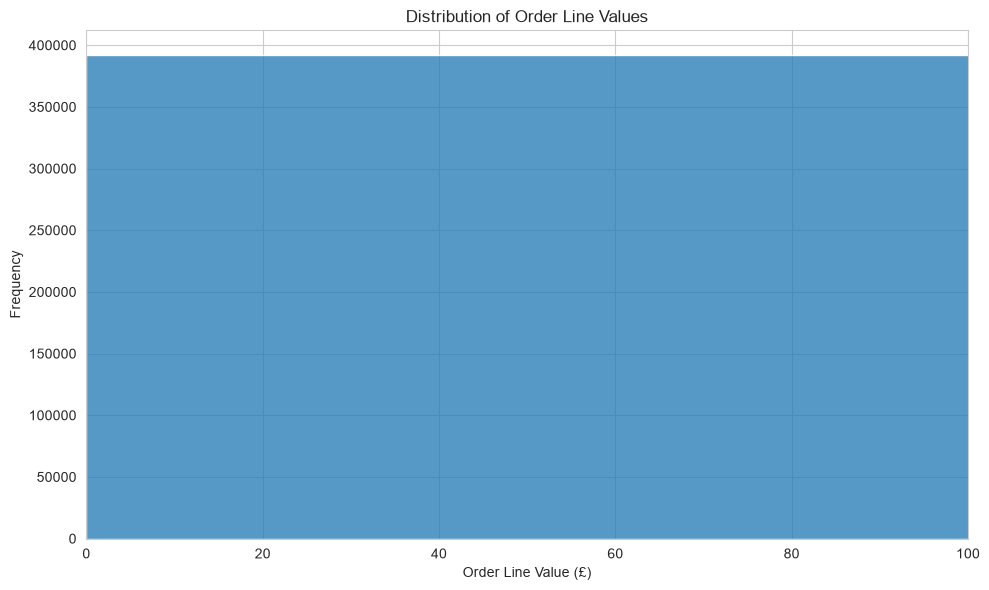

In [35]:
plt.figure(figsize=(10,6))
sns.histplot(df_clean['TotalPrice'], bins=50, kde=False)
plt.title('Distribution of Order Line Values')
plt.xlabel('Order Line Value (£)')
plt.ylabel('Frequency')
plt.xlim(0, 100)  # zoom in, since a few extreme outliers would otherwise squash the chart
plt.tight_layout()
plt.show()

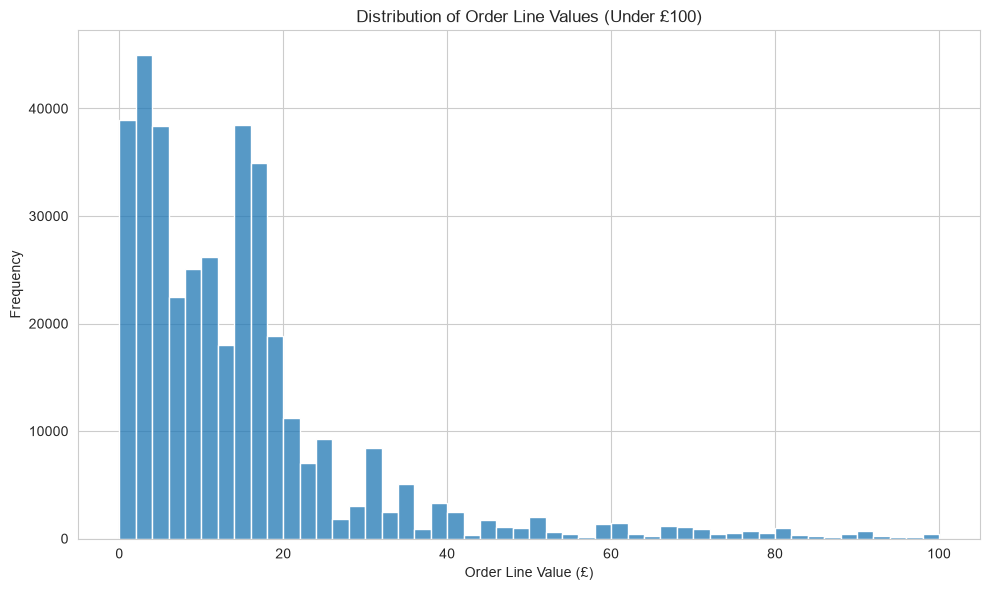

In [36]:
plt.figure(figsize=(10,6))
sns.histplot(df_clean[df_clean['TotalPrice'] <= 100]['TotalPrice'], bins=50, kde=False)
plt.title('Distribution of Order Line Values (Under £100)')
plt.xlabel('Order Line Value (£)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [37]:
pct_under_100 = (df_clean['TotalPrice'] <= 100).mean() * 100
print(f"{pct_under_100:.2f}% of order lines are under £100")

97.05% of order lines are under £100


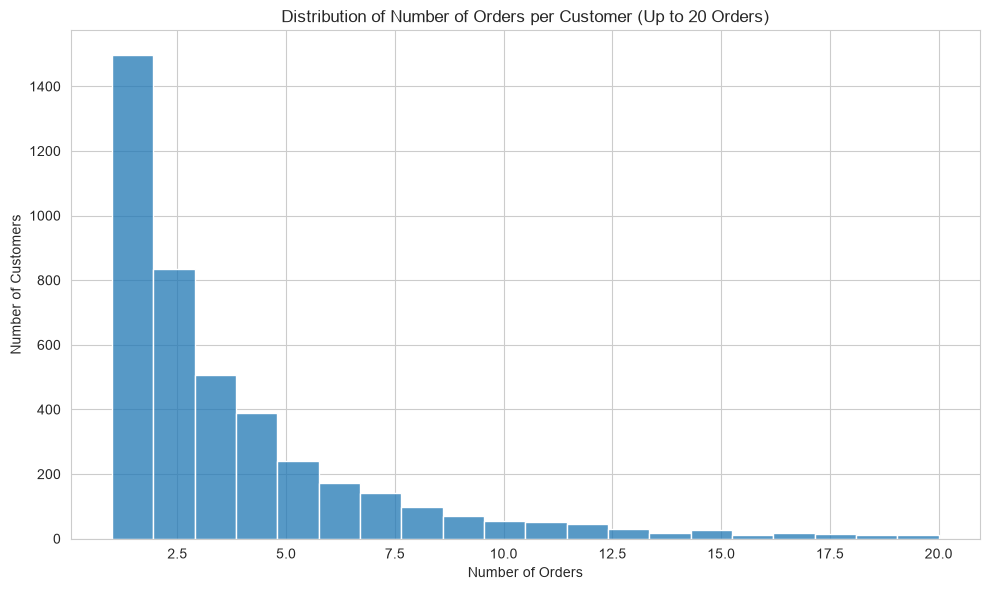

In [38]:
# Count number of unique invoices (orders) per customer
customer_orders = df_clean.groupby('CustomerID')['InvoiceNo'].nunique()

plt.figure(figsize=(10,6))
sns.histplot(customer_orders[customer_orders <= 20], bins=20, kde=False)
plt.title('Distribution of Number of Orders per Customer (Up to 20 Orders)')
plt.xlabel('Number of Orders')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

In [39]:
print(customer_orders.describe())
print("Customers with only 1 order:", (customer_orders == 1).sum())
print("Percentage one-time buyers:", (customer_orders == 1).mean() * 100)

count    4336.000000
mean        4.259686
std         7.661398
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max       206.000000
Name: InvoiceNo, dtype: float64
Customers with only 1 order: 1498
Percentage one-time buyers: 34.5479704797048


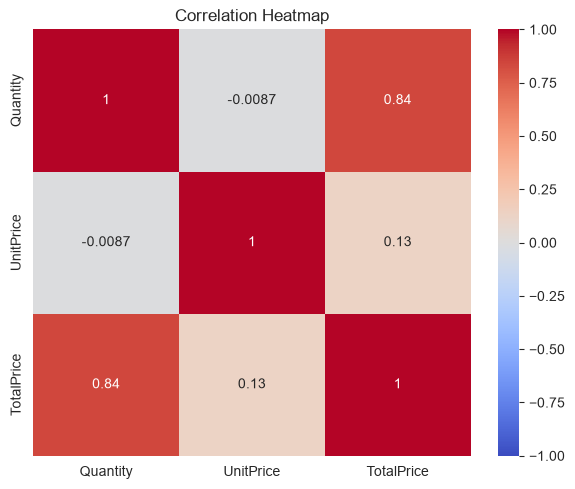

In [40]:
corr_matrix = df_clean[['Quantity', 'UnitPrice', 'TotalPrice']].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [41]:
import datetime as dt

# Set a reference date (one day after the last transaction in the dataset)
reference_date = df_clean['InvoiceDate'].max() + dt.timedelta(days=1)

rfm = df_clean.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


In [43]:
%pip install scikit-learn
from sklearn.model_selection import train_test_split

X = rfm[['Recency', 'Frequency']]
y = rfm['Monetary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)

  Using cached scikit_learn-1.9.0-cp313-cp313-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached scipy-1.18.0-cp313-cp313-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached narwhals-2.23.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.9.0-cp313-cp313-macosx_12_0_arm64.whl (8.2 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scipy-1.18.0-cp313-cp313-macosx_14_0_arm64.whl (20.4 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
Note: you may need to restart the kernel to use updated packages.
(3468, 2) (868, 2)


In [44]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [  1.71622548 597.92860856]
Intercept: -723.404532445111


In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")

MAE: 1298.96
RMSE: 7978.80
R²: 0.4164


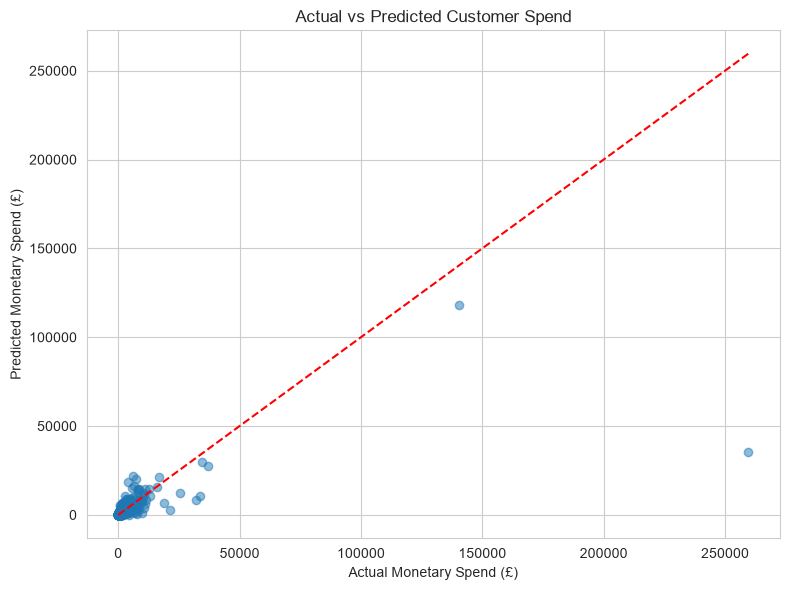

In [46]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel('Actual Monetary Spend (£)')
plt.ylabel('Predicted Monetary Spend (£)')
plt.title('Actual vs Predicted Customer Spend')
plt.tight_layout()
plt.show()

In [47]:
# Check top 5 actual spenders in the test set and how badly they're predicted
comparison = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
comparison['Error'] = comparison['Actual'] - comparison['Predicted']
comparison.sort_values('Actual', ascending=False).head(5)

,Actual,Predicted,Error
4199,259657.30,35154.028207,224503.271793
1880,140336.83,118266.104796,22070.725204
2688,37130.60,27386.104972,9744.495028
2990,34684.40,29800.130337,4884.269663
2570,33643.08,10656.117510,22986.962490


In [48]:
import pandas as pd

comparison = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
comparison['Error'] = comparison['Actual'] - comparison['Predicted']
comparison.sort_values('Actual', ascending=False).head(5)

,Actual,Predicted,Error
4199,259657.30,35154.028207,224503.271793
1880,140336.83,118266.104796,22070.725204
2688,37130.60,27386.104972,9744.495028
2990,34684.40,29800.130337,4884.269663
2570,33643.08,10656.117510,22986.962490
